# Homework 3: Sequence-to-Sequence Machine Translation

**Name:** Gilberto Feliu  
**Student ID:** 801257813  
**Assignment:** Homework 3

This notebook is the primary reproducible source for the Homework 3 report. It loads the dataset, defines the baseline and attention-based seq2seq models, trains all four required experiments, computes evaluation metrics, and regenerates the exact CSV and PNG artifacts referenced by the report.

## Environment and Dataset Check

The notebook expects the provided dataset at `data/vast_english_french.txt` and writes regenerated outputs into `results/` and `plots/`.

In [1]:
from pathlib import Path

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "vast_english_french.txt"
RESULTS_DIR = ROOT / "results"
PLOTS_DIR = ROOT / "plots"

print("Working directory:", ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())
if not DATA_PATH.exists():
    raise FileNotFoundError("Place vast_english_french.txt in Homework_3/data/ before executing this notebook.")

Working directory: /home/gilberto/Homework_3
Dataset path: /home/gilberto/Homework_3/data/vast_english_french.txt
Dataset exists: True


## Model and Utility Definitions

The following cell contains the full implementation used for the homework experiments.

In [2]:
import argparse
import csv
import json
import math
import random
import re
import time
import unicodedata
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


PAD = "<pad>"
SOS = "<sos>"
EOS = "<eos>"
UNK = "<unk>"
SPECIALS = [PAD, SOS, EOS, UNK]


def normalize_text(text):
    text = unicodedata.normalize("NFD", text.lower().strip())
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    text = re.sub(r"([.!?;,])", r" \1", text)
    text = re.sub(r"[^a-zA-Z.!?;,']+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def load_pairs(path):
    pairs = []
    with Path(path).open("r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue
            if "\t" in line:
                left, right = line.split("\t")[:2]
            elif "|||" in line:
                left, right = line.split("|||")[:2]
            else:
                raise ValueError(
                    "Expected each dataset row to contain tab-separated or |||-separated English/French text."
                )
            pairs.append((normalize_text(left), normalize_text(right)))
    if len(pairs) < 10:
        raise ValueError("Dataset is too small after parsing.")
    return pairs


def split_pairs(pairs, seed=4106, train_fraction=0.8):
    rng = random.Random(seed)
    indices = list(range(len(pairs)))
    rng.shuffle(indices)
    cutoff = int(len(indices) * train_fraction)
    train_idx = indices[:cutoff]
    val_idx = indices[cutoff:]
    return [pairs[i] for i in train_idx], [pairs[i] for i in val_idx], train_idx, val_idx


class Vocab:
    def __init__(self, texts, min_freq=1, max_size=None):
        counts = Counter()
        for text in texts:
            counts.update(text.split())
        words = [w for w, c in counts.items() if c >= min_freq]
        words.sort(key=lambda w: (-counts[w], w))
        if max_size:
            words = words[: max(0, max_size - len(SPECIALS))]
        self.itos = SPECIALS + words
        self.stoi = {word: i for i, word in enumerate(self.itos)}
        self.pad_idx = self.stoi[PAD]
        self.sos_idx = self.stoi[SOS]
        self.eos_idx = self.stoi[EOS]
        self.unk_idx = self.stoi[UNK]

    def encode(self, text, add_boundaries=True):
        ids = [self.stoi.get(tok, self.unk_idx) for tok in text.split()]
        if add_boundaries:
            return [self.sos_idx] + ids + [self.eos_idx]
        return ids

    def decode(self, ids):
        words = []
        for idx in ids:
            idx = int(idx)
            if idx == self.eos_idx:
                break
            if idx in (self.pad_idx, self.sos_idx):
                continue
            words.append(self.itos[idx] if idx < len(self.itos) else UNK)
        return " ".join(words)

    def __len__(self):
        return len(self.itos)


class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.rows = [
            (
                torch.tensor(src_vocab.encode(src), dtype=torch.long),
                torch.tensor(tgt_vocab.encode(tgt), dtype=torch.long),
                src,
                tgt,
            )
            for src, tgt in pairs
        ]

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        return self.rows[idx]


def collate_batch(rows):
    src, tgt, src_text, tgt_text = zip(*rows)
    src_lens = torch.tensor([len(x) for x in src], dtype=torch.long)
    tgt_lens = torch.tensor([len(x) for x in tgt], dtype=torch.long)
    src_pad = nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=0)
    tgt_pad = nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=0)
    return src_pad, src_lens, tgt_pad, tgt_lens, list(src_text), list(tgt_text)


class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False
        )
        outputs, hidden = self.gru(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        return outputs, hidden


class BaselineDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, hidden, encoder_outputs=None, src_mask=None):
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))
        output, hidden = self.gru(embedded, hidden)
        logits = self.out(output.squeeze(1))
        return logits, hidden, None


class LuongAttentionDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, hidden, encoder_outputs, src_mask):
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))
        scores = torch.bmm(encoder_outputs, hidden[-1].unsqueeze(2)).squeeze(2)
        scores = scores.masked_fill(~src_mask, -1e9)
        attn = F.softmax(scores, dim=1)
        context = torch.bmm(attn.unsqueeze(1), encoder_outputs)
        gru_input = torch.cat([embedded, context], dim=2)
        output, hidden = self.gru(gru_input, hidden)
        logits = self.out(torch.cat([output.squeeze(1), context.squeeze(1)], dim=1))
        return logits, hidden, attn


class Seq2Seq(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, emb_dim=128, hidden_dim=256, dropout=0.2, attention=False):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, emb_dim, hidden_dim, dropout)
        decoder_cls = LuongAttentionDecoder if attention else BaselineDecoder
        self.decoder = decoder_cls(tgt_vocab_size, emb_dim, hidden_dim, dropout)
        self.attention = attention

    def forward(self, src, src_lens, tgt, teacher_forcing=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.out.out_features
        outputs = torch.zeros(batch_size, tgt_len - 1, vocab_size, device=src.device)
        encoder_outputs, hidden = self.encoder(src, src_lens)
        src_mask = torch.arange(src.shape[1], device=src.device).unsqueeze(0) < src_lens.unsqueeze(1).to(src.device)
        input_token = tgt[:, 0]
        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder.forward_step(input_token, hidden, encoder_outputs, src_mask)
            outputs[:, t - 1] = logits
            use_teacher = random.random() < teacher_forcing
            input_token = tgt[:, t] if use_teacher else logits.argmax(1)
        return outputs

    @torch.no_grad()
    def generate(self, src, src_lens, sos_idx, eos_idx, max_len=40):
        self.eval()
        encoder_outputs, hidden = self.encoder(src, src_lens)
        src_mask = torch.arange(src.shape[1], device=src.device).unsqueeze(0) < src_lens.unsqueeze(1).to(src.device)
        input_token = torch.full((src.shape[0],), sos_idx, dtype=torch.long, device=src.device)
        sequences = []
        attentions = []
        finished = torch.zeros(src.shape[0], dtype=torch.bool, device=src.device)
        for _ in range(max_len):
            logits, hidden, attn = self.decoder.forward_step(input_token, hidden, encoder_outputs, src_mask)
            input_token = logits.argmax(1)
            sequences.append(input_token)
            if attn is not None:
                attentions.append(attn)
            finished |= input_token.eq(eos_idx)
            if bool(finished.all()):
                break
        pred = torch.stack(sequences, dim=1) if sequences else torch.empty(src.shape[0], 0, device=src.device)
        attn_tensor = torch.stack(attentions, dim=1) if attentions else None
        return pred, attn_tensor


def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1))


def sentence_bleu(reference, hypothesis, max_n=4):
    ref = reference.split()
    hyp = hypothesis.split()
    if not hyp:
        return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        hyp_counts = ngram_counts(hyp, n)
        ref_counts = ngram_counts(ref, n)
        total = sum(hyp_counts.values())
        overlap = sum(min(count, ref_counts[gram]) for gram, count in hyp_counts.items())
        precisions.append((overlap + 1.0) / (total + 1.0))
    bp = 1.0 if len(hyp) > len(ref) else math.exp(1.0 - len(ref) / max(1, len(hyp)))
    return bp * math.exp(sum(math.log(p) for p in precisions) / max_n)


def corpus_bleu(references, hypotheses, max_n=4, tokenizer=None):
    if not hypotheses:
        return 0.0
    tokenizer = tokenizer or (lambda text: text.split())
    matches = [0] * max_n
    totals = [0] * max_n
    ref_len = 0
    hyp_len = 0
    for reference, hypothesis in zip(references, hypotheses):
        ref = tokenizer(reference)
        hyp = tokenizer(hypothesis)
        ref_len += len(ref)
        hyp_len += len(hyp)
        for n in range(1, max_n + 1):
            hyp_counts = ngram_counts(hyp, n)
            ref_counts = ngram_counts(ref, n)
            matches[n - 1] += sum(min(count, ref_counts[gram]) for gram, count in hyp_counts.items())
            totals[n - 1] += sum(hyp_counts.values())
    precisions = [(matches[i] + 1.0) / (totals[i] + 1.0) for i in range(max_n)]
    bp = 1.0 if hyp_len > ref_len else math.exp(1.0 - ref_len / max(1, hyp_len))
    return bp * math.exp(sum(math.log(p) for p in precisions) / max_n)


def char_accuracy(reference, hypothesis):
    if not reference:
        return 1.0 if not hypothesis else 0.0
    matches = sum(1 for a, b in zip(reference, hypothesis) if a == b)
    return matches / len(reference)


def sequence_similarity(reference, hypothesis):
    return SequenceMatcher(None, reference, hypothesis).ratio()


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train(train)
    total_loss = 0.0
    total_tokens = 0
    for src, src_lens, tgt, _tgt_lens, *_ in loader:
        src, src_lens, tgt = src.to(device), src_lens.to(device), tgt.to(device)
        if train:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            outputs = model(src, src_lens, tgt, teacher_forcing=0.5 if train else 0.0)
            gold = tgt[:, 1:]
            loss = criterion(outputs.reshape(-1, outputs.shape[-1]), gold.reshape(-1))
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        tokens = gold.ne(0).sum().item()
        total_loss += loss.item() * tokens
        total_tokens += tokens
    return total_loss / max(1, total_tokens)


@torch.no_grad()
def evaluate_generation(model, loader, src_vocab, tgt_vocab, device, max_len=40):
    predictions, references, sources = [], [], []
    sample_attn = []
    for src, src_lens, _tgt, _tgt_lens, src_text, tgt_text in loader:
        src, src_lens = src.to(device), src_lens.to(device)
        pred_ids, attn = model.generate(src, src_lens, tgt_vocab.sos_idx, tgt_vocab.eos_idx, max_len=max_len)
        for row in pred_ids.cpu():
            predictions.append(tgt_vocab.decode(row.tolist()))
        references.extend(tgt_text)
        sources.extend(src_text)
        if attn is not None and len(sample_attn) < 2:
            for b in range(min(src.shape[0], 2 - len(sample_attn))):
                pred_tokens = predictions[-src.shape[0] + b].split()
                src_tokens = sources[-src.shape[0] + b].split()
                sample_attn.append(
                    {
                        "source": src_tokens,
                        "prediction": pred_tokens,
                        "weights": attn[b, : len(pred_tokens), : len(src_tokens)].cpu(),
                    }
                )
    exact = sum(p == r for p, r in zip(predictions, references)) / max(1, len(references))
    word_bleu = corpus_bleu(references, predictions)
    char_bleu = corpus_bleu(references, predictions, tokenizer=list)
    char_acc = sum(char_accuracy(r, p) for r, p in zip(references, predictions)) / max(1, len(references))
    seq_sim = sum(sequence_similarity(r, p) for r, p in zip(references, predictions)) / max(1, len(references))
    return {
        "sources": sources,
        "references": references,
        "predictions": predictions,
        "exact_match": exact,
        "word_bleu4": word_bleu,
        "char_bleu4": char_bleu,
        "char_accuracy": char_acc,
        "sequence_similarity": seq_sim,
        "attention_samples": sample_attn,
    }


def save_loss_plot(history, out_path, title):
    plt.figure(figsize=(7, 4.5))
    plt.plot(history["epoch"], history["train_loss"], marker="o", label="Training loss")
    plt.plot(history["epoch"], history["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=180)
    plt.close()


def save_attention_map(sample, out_path, title):
    weights = sample["weights"]
    if weights.numel() == 0:
        return
    plt.figure(figsize=(max(5, len(sample["source"]) * 0.55), max(4, len(sample["prediction"]) * 0.45)))
    plt.imshow(weights, aspect="auto", cmap="viridis")
    plt.colorbar(label="Attention weight")
    plt.xticks(range(len(sample["source"])), sample["source"], rotation=45, ha="right")
    plt.yticks(range(len(sample["prediction"])), sample["prediction"])
    plt.xlabel("Source tokens")
    plt.ylabel("Predicted target tokens")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180)
    plt.close()


def write_history_csv(history, path):
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "val_loss"])
        writer.writeheader()
        for i in range(len(history["epoch"])):
            writer.writerow({k: history[k][i] for k in writer.fieldnames})


def write_samples_csv(eval_result, path, limit=5):
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        fields = [
            "source",
            "reference",
            "prediction",
            "exact_match",
            "sentence_bleu4",
            "char_accuracy",
            "sequence_similarity",
        ]
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for src, ref, pred in zip(eval_result["sources"][:limit], eval_result["references"][:limit], eval_result["predictions"][:limit]):
            writer.writerow(
                {
                    "source": src,
                    "reference": ref,
                    "prediction": pred,
                    "exact_match": int(pred == ref),
                    "sentence_bleu4": f"{sentence_bleu(ref, pred):.4f}",
                    "char_accuracy": f"{char_accuracy(ref, pred):.4f}",
                    "sequence_similarity": f"{sequence_similarity(ref, pred):.4f}",
                }
            )


def train_one_experiment(name, train_pairs, val_pairs, results_dir, plots_dir, args, reverse=False, attention=False):
    if reverse:
        train_pairs = [(fr, en) for en, fr in train_pairs]
        val_pairs = [(fr, en) for en, fr in val_pairs]
    src_vocab = Vocab([src for src, _ in train_pairs], min_freq=args.min_freq, max_size=args.max_vocab)
    tgt_vocab = Vocab([tgt for _, tgt in train_pairs], min_freq=args.min_freq, max_size=args.max_vocab)
    train_ds = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
    val_ds = TranslationDataset(val_pairs, src_vocab, tgt_vocab)
    train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True, collate_fn=collate_batch)
    val_loader = DataLoader(val_ds, batch_size=args.batch_size, shuffle=False, collate_fn=collate_batch)
    device = torch.device("cuda" if torch.cuda.is_available() and not args.cpu else "cpu")
    model = Seq2Seq(len(src_vocab), len(tgt_vocab), args.emb_dim, args.hidden_dim, args.dropout, attention).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_idx)
    history = {"epoch": [], "train_loss": [], "val_loss": []}
    best_state = None
    best_val = float("inf")
    start = time.time()
    for epoch in range(1, args.epochs + 1):
        train_loss = run_epoch(model, train_loader, optimizer, criterion, device, train=True)
        val_loss = run_epoch(model, val_loader, optimizer, criterion, device, train=False)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"{name}: epoch {epoch:02d} train_loss={train_loss:.4f} val_loss={val_loss:.4f}")
    if best_state:
        model.load_state_dict(best_state)
    eval_result = evaluate_generation(model, val_loader, src_vocab, tgt_vocab, device, max_len=args.max_decode_len)
    history_path = results_dir / f"{name}_history.csv"
    samples_path = results_dir / f"{name}_samples.csv"
    write_history_csv(history, history_path)
    write_samples_csv(eval_result, samples_path, limit=5)
    save_loss_plot(history, plots_dir / f"{name}_loss.png", name.replace("_", " ").title())
    if attention:
        for i, sample in enumerate(eval_result["attention_samples"], start=1):
            save_attention_map(sample, plots_dir / f"{name}_attention_{i}.png", f"{name} attention sample {i}")
    return {
        "experiment": name,
        "direction": "French-to-English" if reverse else "English-to-French",
        "architecture": "GRU with Luong attention" if attention else "Baseline GRU encoder-decoder",
        "train_size": len(train_ds),
        "validation_size": len(val_ds),
        "source_vocab": len(src_vocab),
        "target_vocab": len(tgt_vocab),
        "best_val_loss": best_val,
        "exact_match": eval_result["exact_match"],
        "word_bleu4": eval_result["word_bleu4"],
        "char_bleu4": eval_result["char_bleu4"],
        "char_accuracy": eval_result["char_accuracy"],
        "sequence_similarity": eval_result["sequence_similarity"],
        "seconds": time.time() - start,
        "history_csv": str(history_path),
        "samples_csv": str(samples_path),
    }

/home/gilberto/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Training Configuration

These hyperparameters match the report configuration and regenerate the same artifact filenames used throughout the repository.

In [3]:
class NotebookArgs:
    data = "data/vast_english_french.txt"
    epochs = 60
    batch_size = 96
    emb_dim = 128
    hidden_dim = 160
    dropout = 0.2
    lr = 0.001
    seed = 4106
    min_freq = 1
    max_vocab = None
    max_decode_len = 40
    cpu = False
    quick = False


args = NotebookArgs()
args

## Run All Four Experiments

This cell performs the deterministic split, trains the models, writes `results/*.csv`, and generates the per-model loss and attention plots under `plots/`.

In [4]:
random.seed(args.seed)
torch.manual_seed(args.seed)

RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

pairs = load_pairs(DATA_PATH)
train_pairs, val_pairs, train_idx, val_idx = split_pairs(pairs, seed=args.seed)

with (RESULTS_DIR / "split_indices.json").open("w", encoding="utf-8") as f:
    json.dump(
        {"seed": args.seed, "train_indices": train_idx, "validation_indices": val_idx},
        f,
        indent=2,
    )

experiments = [
    ("problem1_baseline_en_fr", False, False),
    ("problem2_attention_en_fr", False, True),
    ("problem3_baseline_fr_en", True, False),
    ("problem3_attention_fr_en", True, True),
]

summaries = []
for name, reverse, attention in experiments:
    summaries.append(
        train_one_experiment(
            name,
            train_pairs,
            val_pairs,
            RESULTS_DIR,
            PLOTS_DIR,
            args,
            reverse=reverse,
            attention=attention,
        )
    )

with (RESULTS_DIR / "summary.csv").open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(summaries[0].keys()))
    writer.writeheader()
    writer.writerows(summaries)

print("\nFinal validation summary")
for row in summaries:
    print(
        f"{row['experiment']}: val_loss={row['best_val_loss']:.4f}, "
        f"exact={row['exact_match']:.4f}, word BLEU-4={row['word_bleu4']:.4f}"
    )

problem1_baseline_en_fr: epoch 01 train_loss=6.8542 val_loss=6.7705
problem1_baseline_en_fr: epoch 02 train_loss=6.5933 val_loss=6.3720
problem1_baseline_en_fr: epoch 03 train_loss=6.1616 val_loss=5.8676


problem1_baseline_en_fr: epoch 04 train_loss=5.5689 val_loss=5.7226
problem1_baseline_en_fr: epoch 05 train_loss=5.2755 val_loss=5.7492
problem1_baseline_en_fr: epoch 06 train_loss=5.1607 val_loss=5.7503
problem1_baseline_en_fr: epoch 07 train_loss=5.0863 val_loss=5.6876


problem1_baseline_en_fr: epoch 08 train_loss=4.9952 val_loss=5.6493
problem1_baseline_en_fr: epoch 09 train_loss=4.9404 val_loss=5.6818
problem1_baseline_en_fr: epoch 10 train_loss=4.9064 val_loss=5.6686


problem1_baseline_en_fr: epoch 11 train_loss=4.8367 val_loss=5.6669
problem1_baseline_en_fr: epoch 12 train_loss=4.7665 val_loss=5.6624
problem1_baseline_en_fr: epoch 13 train_loss=4.7396 val_loss=5.6437
problem1_baseline_en_fr: epoch 14 train_loss=4.6748 val_loss=5.5988


problem1_baseline_en_fr: epoch 15 train_loss=4.6195 val_loss=5.5763
problem1_baseline_en_fr: epoch 16 train_loss=4.5464 val_loss=5.5524
problem1_baseline_en_fr: epoch 17 train_loss=4.4979 val_loss=5.5122


...

problem3_attention_fr_en: epoch 48 train_loss=0.6218 val_loss=4.9588
problem3_attention_fr_en: epoch 49 train_loss=0.5829 val_loss=4.9723
problem3_attention_fr_en: epoch 50 train_loss=0.5371 val_loss=4.9883
problem3_attention_fr_en: epoch 51 train_loss=0.5005 val_loss=5.0124


problem3_attention_fr_en: epoch 52 train_loss=0.4708 val_loss=5.0626
problem3_attention_fr_en: epoch 53 train_loss=0.4600 val_loss=5.0315
problem3_attention_fr_en: epoch 54 train_loss=0.4740 val_loss=5.0760
problem3_attention_fr_en: epoch 55 train_loss=0.4069 val_loss=5.1216


problem3_attention_fr_en: epoch 56 train_loss=0.3719 val_loss=5.0942
problem3_attention_fr_en: epoch 57 train_loss=0.3704 val_loss=5.1138
problem3_attention_fr_en: epoch 58 train_loss=0.3488 val_loss=5.1537
problem3_attention_fr_en: epoch 59 train_loss=0.3211 val_loss=5.2014


problem3_attention_fr_en: epoch 60 train_loss=0.2952 val_loss=5.1663



Final validation summary
problem1_baseline_en_fr: val_loss=5.2177, exact=0.0000, word BLEU-4=0.0323
problem2_attention_en_fr: val_loss=5.0014, exact=0.0000, word BLEU-4=0.0504
problem3_baseline_fr_en: val_loss=4.8583, exact=0.0000, word BLEU-4=0.0301
problem3_attention_fr_en: val_loss=4.7187, exact=0.0000, word BLEU-4=0.0397


## Comparison Plots

The next cell regenerates the same comparison figures referenced by the report using the freshly written `results/summary.csv` and per-experiment history files.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


ROOT = Path.cwd()
RESULTS = ROOT / "results"
PLOTS = ROOT / "plots"
SUMMARY = pd.read_csv(RESULTS / "summary.csv")


EXPERIMENT_LABELS = {
    "problem1_baseline_en_fr": "Problem 1 Baseline GRU",
    "problem2_attention_en_fr": "Problem 2 Attention GRU",
    "problem3_baseline_fr_en": "Problem 3 Baseline GRU",
    "problem3_attention_fr_en": "Problem 3 Attention GRU",
}

LOSS_TITLES = {
    "problem1_baseline_en_fr": "Problem 1: Baseline GRU English-to-French Loss",
    "problem2_attention_en_fr": "Problem 2: Attention GRU English-to-French Loss",
    "problem3_baseline_fr_en": "Problem 3: Baseline GRU French-to-English Loss",
    "problem3_attention_fr_en": "Problem 3: Attention GRU French-to-English Loss",
}


def improve_loss_plot(experiment):
    history = pd.read_csv(RESULTS / f"{experiment}_history.csv")
    best_idx = history["val_loss"].idxmin()
    best_epoch = int(history.loc[best_idx, "epoch"])
    best_val = float(history.loc[best_idx, "val_loss"])

    plt.figure(figsize=(9, 6))
    plt.plot(history["epoch"], history["train_loss"], marker="o", label="Training Loss")
    plt.plot(history["epoch"], history["val_loss"], marker="o", label="Validation Loss")
    plt.axvline(best_epoch, color="red", linestyle="--", linewidth=2, label=f"Best Val Epoch ({best_epoch})")
    plt.scatter([best_epoch], [best_val], color="red", zorder=5)
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title(LOSS_TITLES[experiment])
    plt.grid(alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS / f"{experiment}_loss.png", dpi=180)
    plt.close()


def make_problem2_comparison():
    rows = SUMMARY[SUMMARY["experiment"].isin(["problem1_baseline_en_fr", "problem2_attention_en_fr"])].copy()
    rows["model"] = rows["experiment"].map(EXPERIMENT_LABELS)
    out = rows[
        [
            "model",
            "best_val_loss",
            "exact_match",
            "word_bleu4",
            "char_bleu4",
            "char_accuracy",
            "sequence_similarity",
            "seconds",
        ]
    ]
    out.to_csv(RESULTS / "problem1_vs_problem2_comparison.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    labels = ["Baseline", "Attention"]
    axes[0].bar(labels, out["word_bleu4"], color=["#4c78a8", "#f58518"])
    axes[0].set_title("English-to-French BLEU-4")
    axes[0].set_ylabel("Word BLEU-4")
    axes[1].bar(labels, out["best_val_loss"], color=["#4c78a8", "#f58518"])
    axes[1].set_title("English-to-French Validation Loss")
    axes[1].set_ylabel("Best Cross-Entropy Loss")
    for ax in axes:
        ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS / "problem1_vs_problem2_comparison.png", dpi=180)
    plt.close()


def make_problem3_comparison():
    rows = SUMMARY.copy()
    rows["model"] = rows["experiment"].map(EXPERIMENT_LABELS)
    rows[
        [
            "model",
            "direction",
            "best_val_loss",
            "exact_match",
            "word_bleu4",
            "char_bleu4",
            "char_accuracy",
            "sequence_similarity",
            "seconds",
        ]
    ].to_csv(RESULTS / "problem3_full_direction_comparison.csv", index=False)

    ordered = [
        "problem1_baseline_en_fr",
        "problem2_attention_en_fr",
        "problem3_baseline_fr_en",
        "problem3_attention_fr_en",
    ]
    rows = rows.set_index("experiment").loc[ordered].reset_index()
    labels = ["EN-FR\nBaseline", "EN-FR\nAttention", "FR-EN\nBaseline", "FR-EN\nAttention"]

    plt.figure(figsize=(9, 5))
    plt.bar(labels, rows["word_bleu4"], color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
    plt.ylabel("Word BLEU-4")
    plt.title("Validation BLEU-4 by Direction and Architecture")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS / "problem3_full_bleu_comparison.png", dpi=180)
    plt.close()

    plt.figure(figsize=(9, 5))
    plt.bar(labels, rows["best_val_loss"], color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
    plt.ylabel("Best Cross-Entropy Loss")
    plt.title("Best Validation Loss by Direction and Architecture")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS / "problem3_model_comparison.png", dpi=180)
    plt.close()

In [6]:
ROOT = Path.cwd()
RESULTS = ROOT / "results"
PLOTS = ROOT / "plots"
SUMMARY = pd.read_csv(RESULTS / "summary.csv")

for experiment in EXPERIMENT_LABELS:
    improve_loss_plot(experiment)
make_problem2_comparison()
make_problem3_comparison()

print("Updated loss plots and comparison artifacts.")

Updated loss plots and comparison artifacts.


## Summary Metrics

In [7]:
summary = pd.read_csv('results/summary.csv')
summary[['experiment', 'direction', 'architecture', 'best_val_loss', 'exact_match', 'word_bleu4', 'char_bleu4', 'sequence_similarity']]

,experiment,direction,architecture,best_val_loss,exact_match,word_bleu4,char_bleu4,sequence_similarity
0,problem1_baseline_en_fr,English-to-French,Baseline GRU encoder-decoder,5.217746,0.0,0.032262,0.141367,0.414702
1,problem2_attention_en_fr,English-to-French,GRU with Luong attention,5.001370,0.0,0.050404,0.234104,0.475961
2,problem3_baseline_fr_en,French-to-English,Baseline GRU encoder-decoder,4.858254,0.0,0.030095,0.143873,0.409807
3,problem3_attention_fr_en,French-to-English,GRU with Luong attention,4.718663,0.0,0.039702,0.185842,0.443277


## Qualitative Samples

In [8]:
for path in sorted(Path('results').glob('*_samples.csv')):
    print(f"\n{path.name}")
    display(pd.read_csv(path))


problem1_baseline_en_fr_samples.csv


,source,reference,prediction,exact_match,sentence_bleu4,char_accuracy,sequence_similarity
0,i can see a large cruise ship in the distance,je peux voir un grand navire de croisiere au loin,je veux une une de de,0,0.1255,0.1633,0.4571
1,she is looking for her lost dog,elle cherche son chien perdu,elle a un un de,0,0.2730,0.2143,0.5116
2,he finished his homework quickly,il a fini ses devoirs rapidement,il a des articles,0,0.2868,0.1875,0.4082
3,we prefer walking through the quiet botanical ...,nous preferons nous promener dans les jardins ...,nous avons visite le lever de,0,0.1340,0.1111,0.3696
4,they visit museums often,ils visitent souvent des musees,ils parlent souvent de,0,0.3097,0.1290,0.6792



problem2_attention_en_fr_samples.csv


,source,reference,prediction,exact_match,sentence_bleu4,char_accuracy,sequence_similarity
0,i can see a large cruise ship in the distance,je peux voir un grand navire de croisiere au loin,elle vois un un navire,0,0.1112,0.0816,0.5070
1,she is looking for her lost dog,elle cherche son chien perdu,elle cherche son son son en en en,0,0.2985,0.6071,0.6885
2,he finished his homework quickly,il a fini ses devoirs rapidement,il a termine son de de de,0,0.2445,0.1875,0.5614
3,we prefer walking through the quiet botanical ...,nous preferons nous promener dans les jardins ...,le train le train du le,0,0.1127,0.0000,0.2558
4,they visit museums often,ils visitent souvent des musees,ils parlent souvent,0,0.3053,0.1290,0.6000



problem3_attention_fr_en_samples.csv


,source,reference,prediction,exact_match,sentence_bleu4,char_accuracy,sequence_similarity
0,je peux voir un grand navire de croisiere au loin,i can see a large cruise ship in the distance,i want a a a a,0,0.1255,0.1111,0.3729
1,elle cherche son chien perdu,she is looking for her lost dog,she cooks her for her,0,0.2588,0.1290,0.5769
2,il a fini ses devoirs rapidement,he finished his homework quickly,he speaks he speaks,0,0.2798,0.0938,0.3922
3,nous preferons nous promener dans les jardins ...,we prefer walking through the quiet botanical ...,we are to the the the,0,0.1752,0.1698,0.4324
4,ils visitent souvent des musees,they visit museums often,they often talk about,0,0.3976,0.2500,0.4444



problem3_baseline_fr_en_samples.csv


,source,reference,prediction,exact_match,sentence_bleu4,char_accuracy,sequence_similarity
0,je peux voir un grand navire de croisiere au loin,i can see a large cruise ship in the distance,i want a a a the the,0,0.1439,0.0889,0.4923
1,elle cherche son chien perdu,she is looking for her lost dog,she wears a a for her,0,0.2644,0.1290,0.5385
2,il a fini ses devoirs rapidement,he finished his homework quickly,he writes his for a,0,0.3021,0.0938,0.5098
3,nous preferons nous promener dans les jardins ...,we prefer walking through the quiet botanical ...,we are going to the the,0,0.1752,0.0943,0.4737
4,ils visitent souvent des musees,they visit museums often,they often talk about,0,0.3976,0.2500,0.4444


## Report Figures

problem1_baseline_en_fr_loss.png


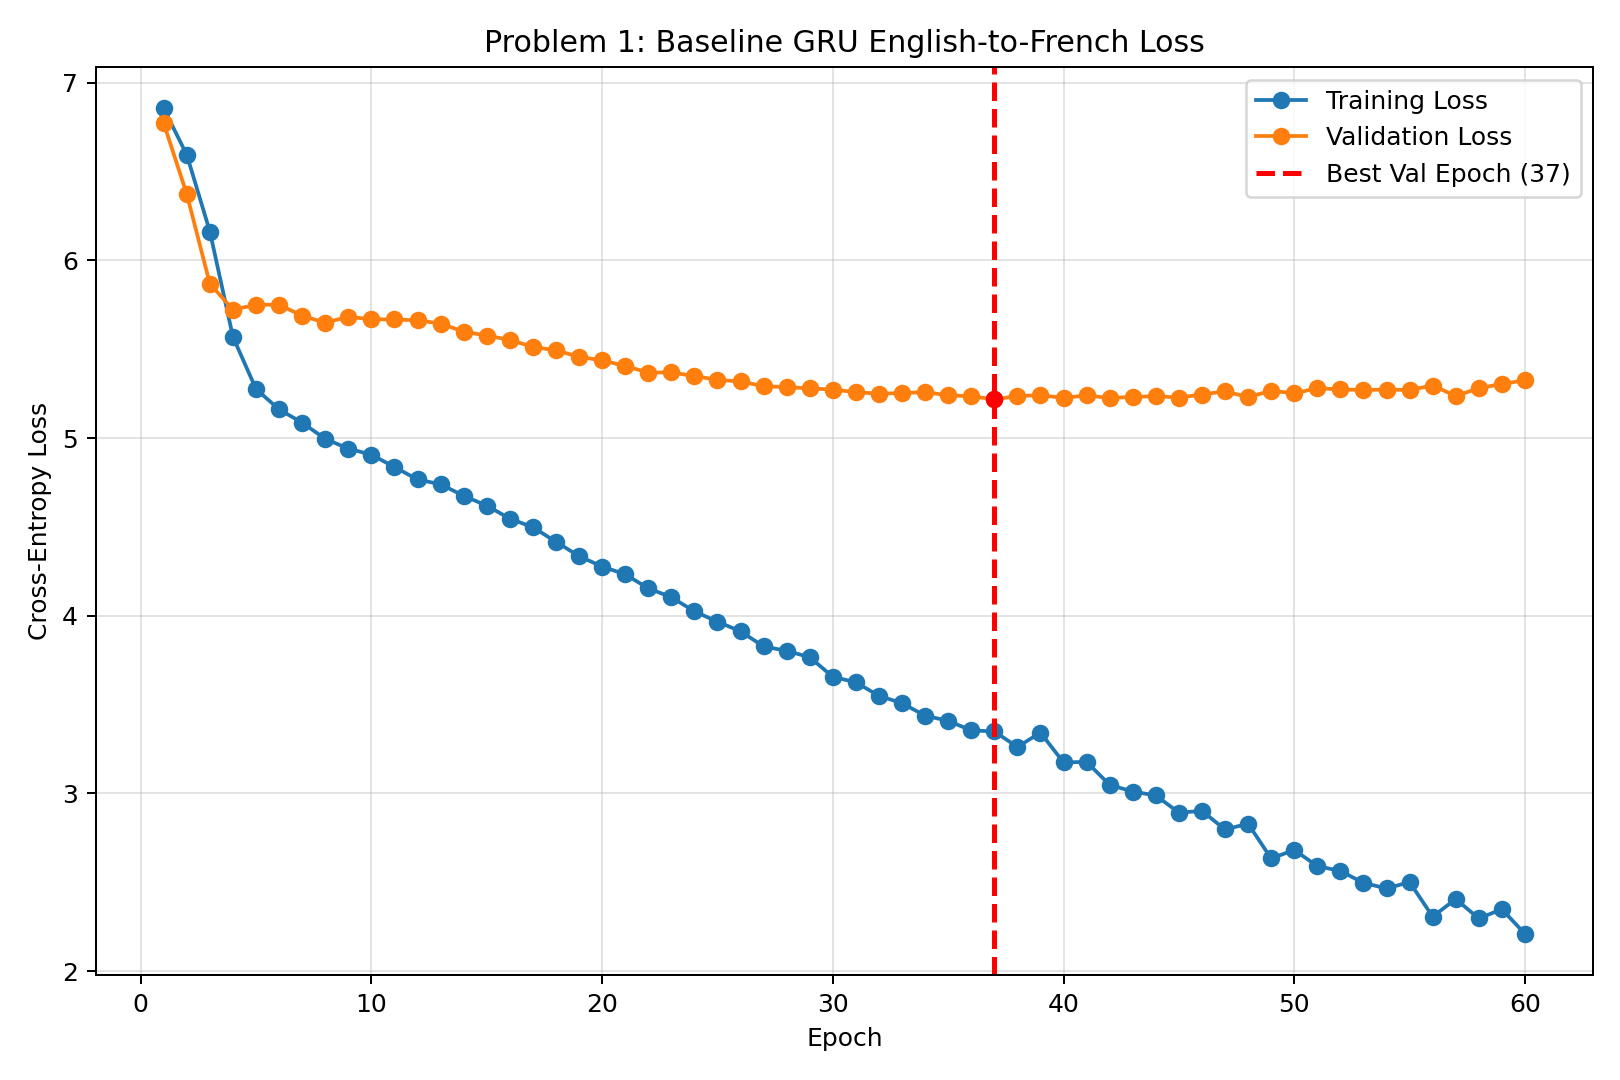

problem1_vs_problem2_comparison.png


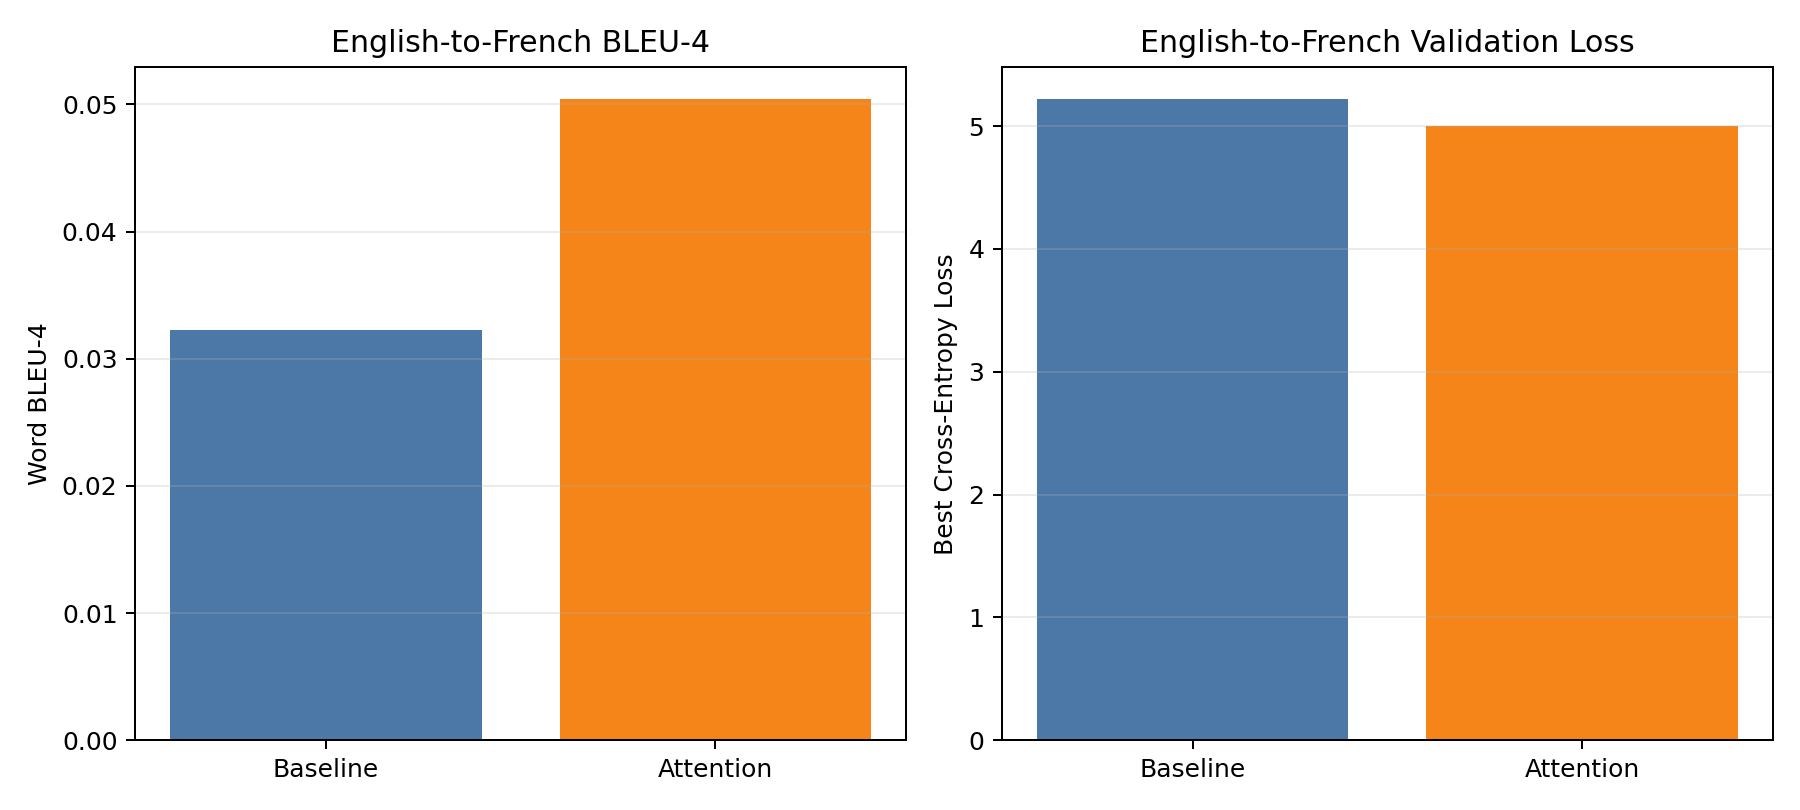

problem2_attention_en_fr_attention_1.png


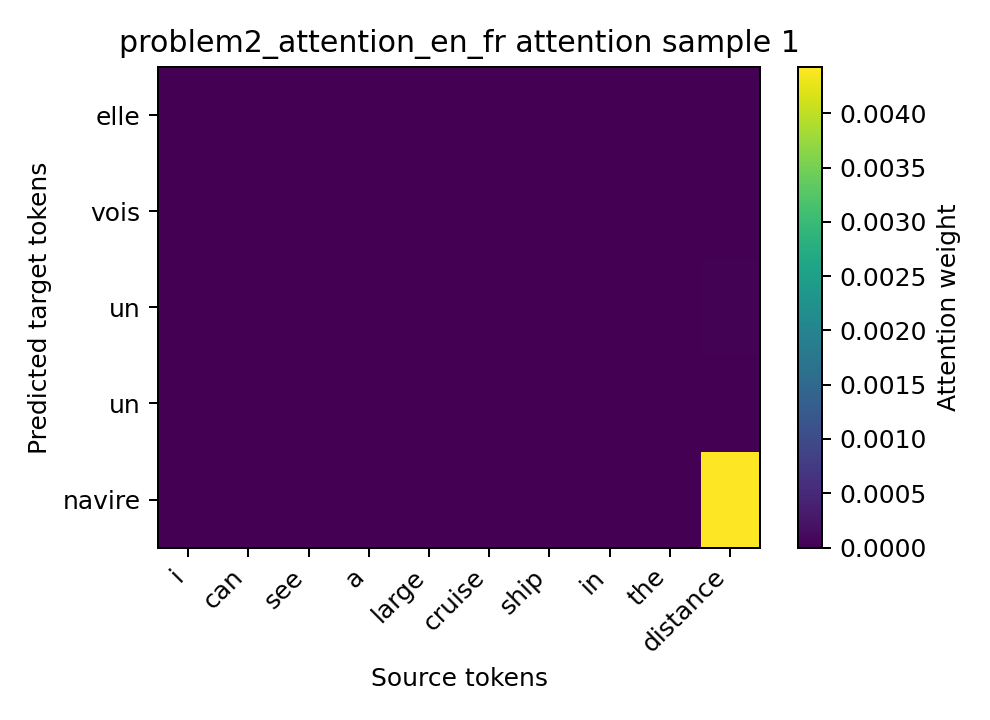

problem2_attention_en_fr_attention_2.png


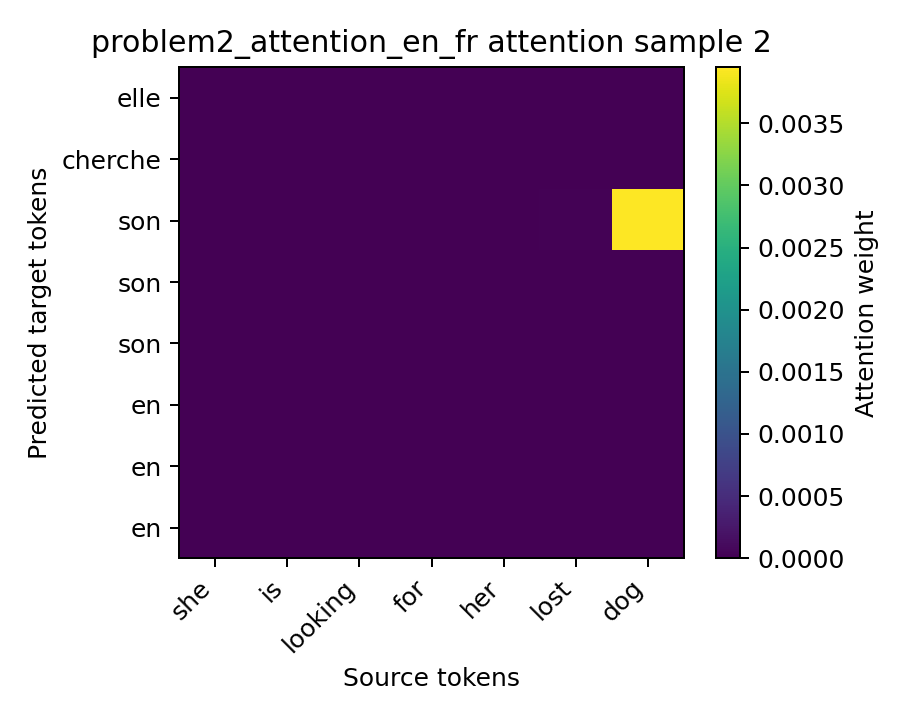

problem2_attention_en_fr_loss.png


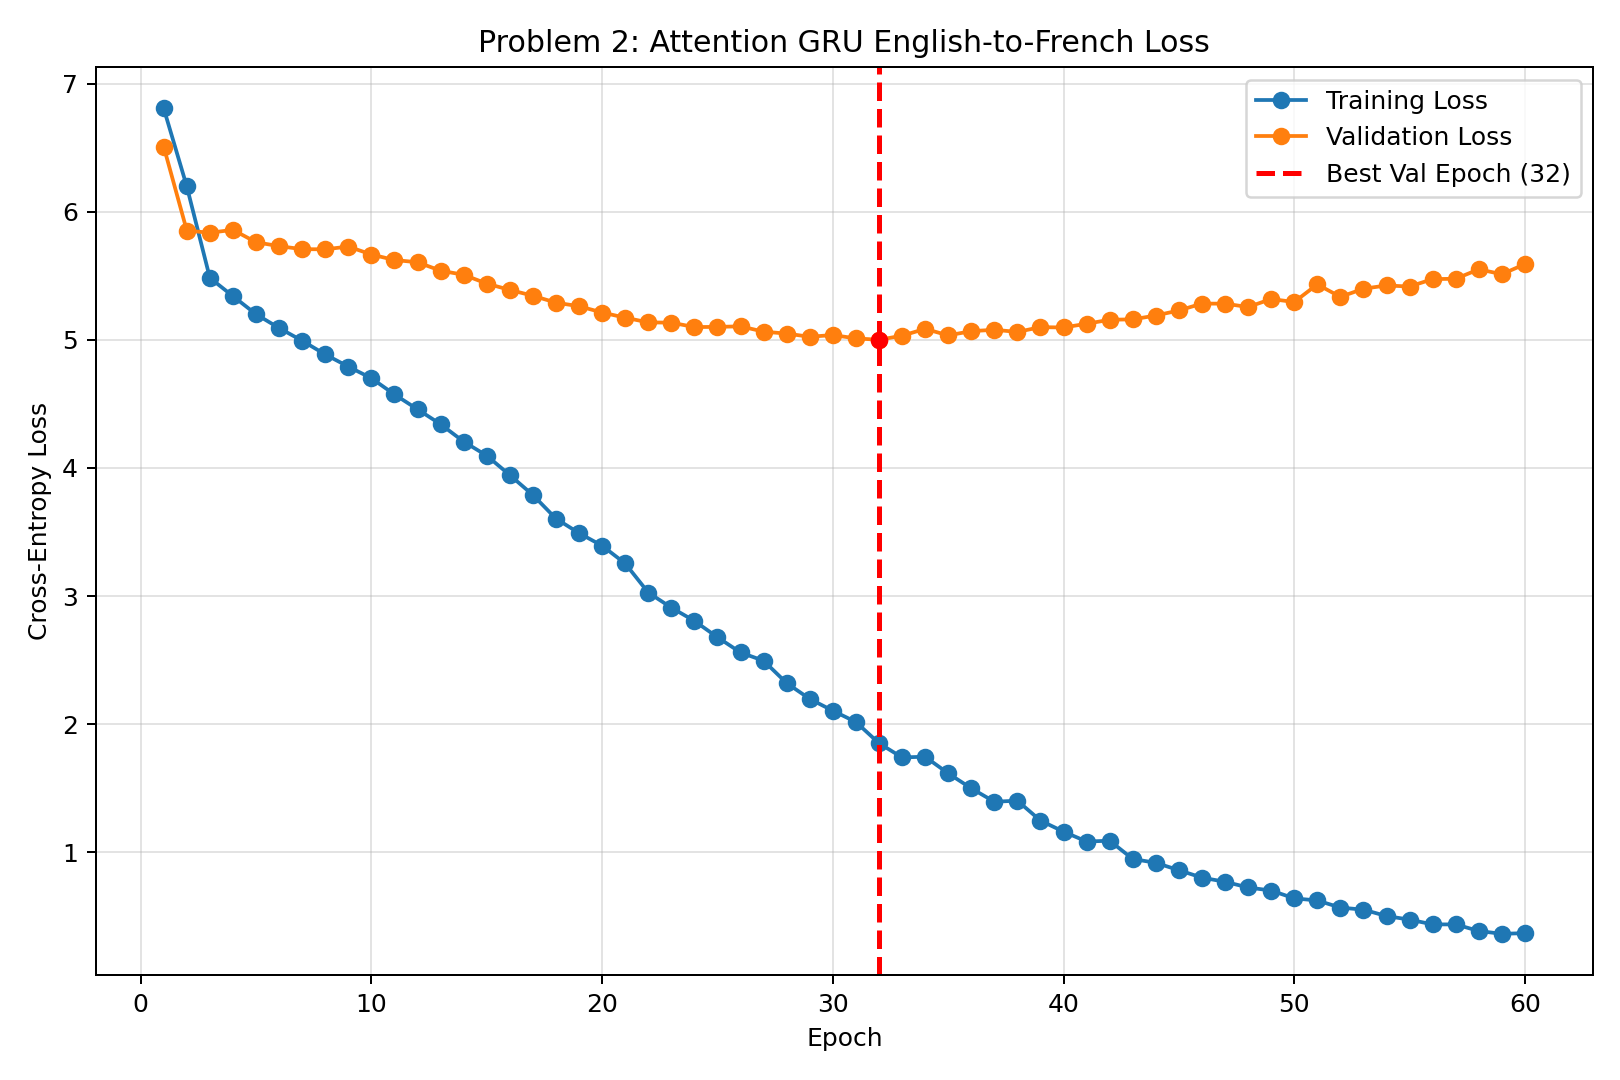

problem3_attention_fr_en_attention_1.png


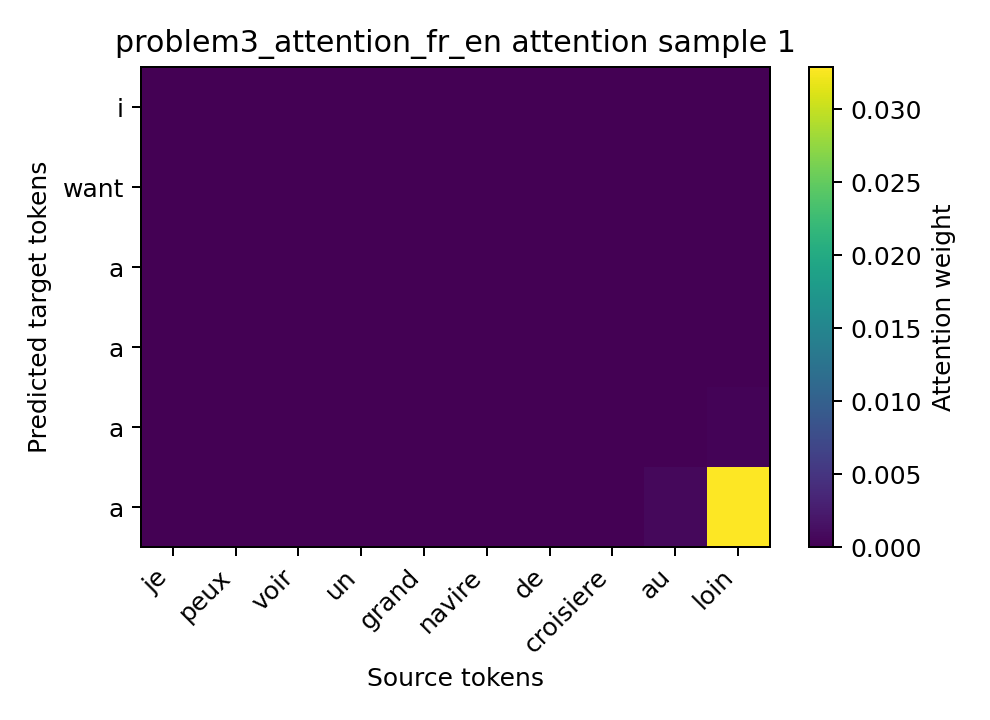

problem3_attention_fr_en_attention_2.png


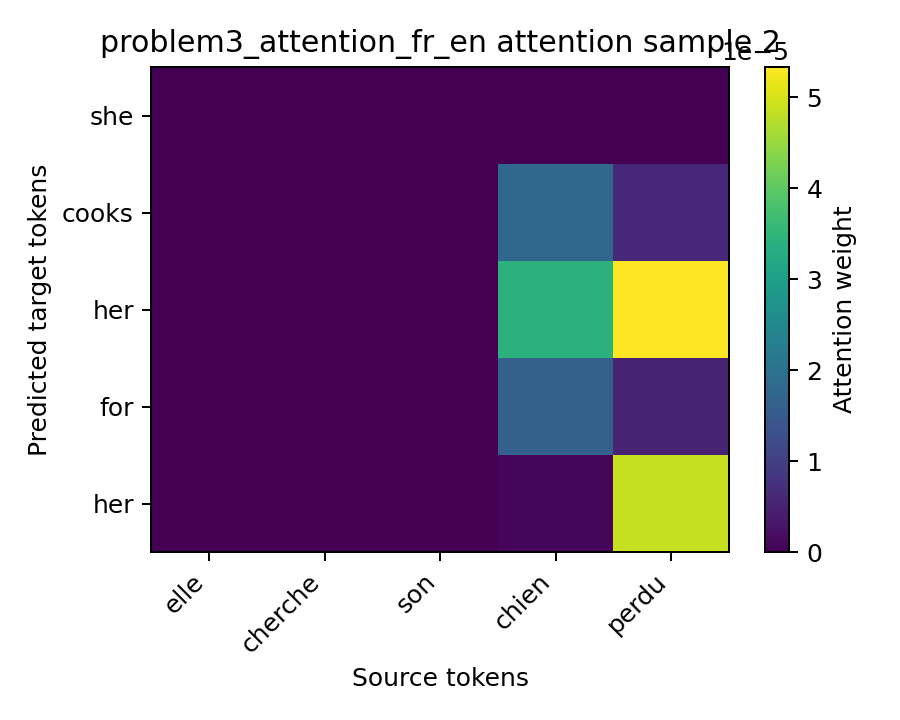

problem3_attention_fr_en_loss.png


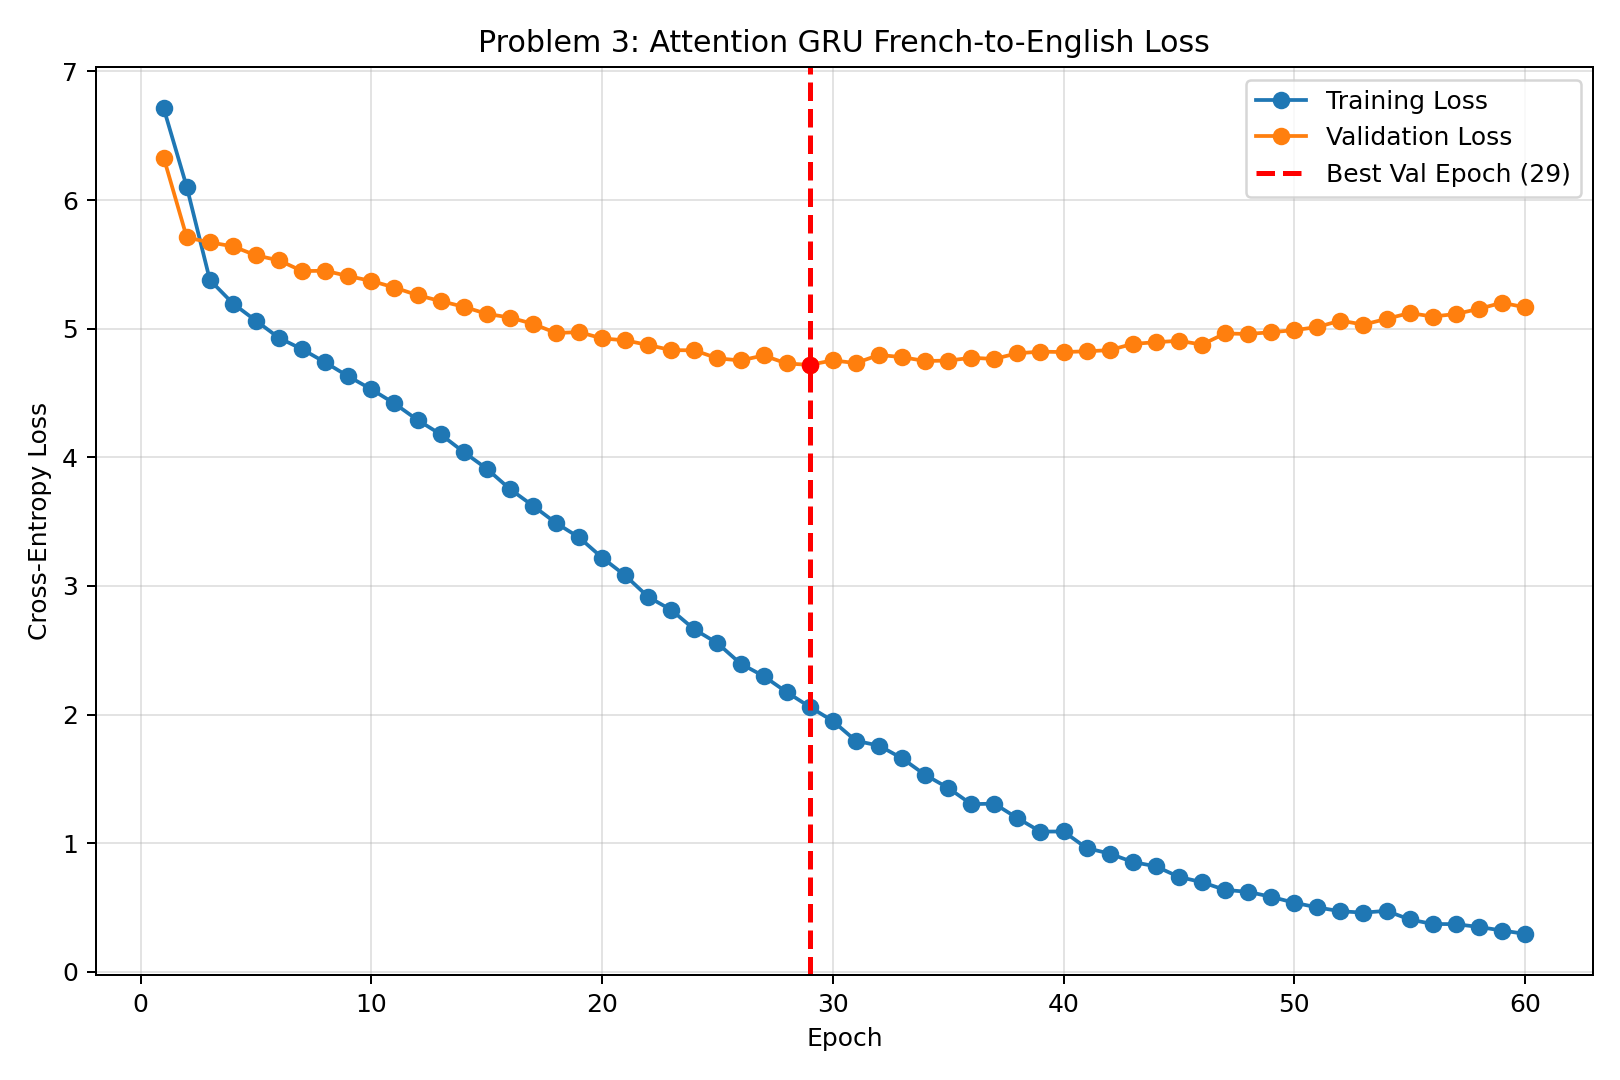

problem3_baseline_fr_en_loss.png


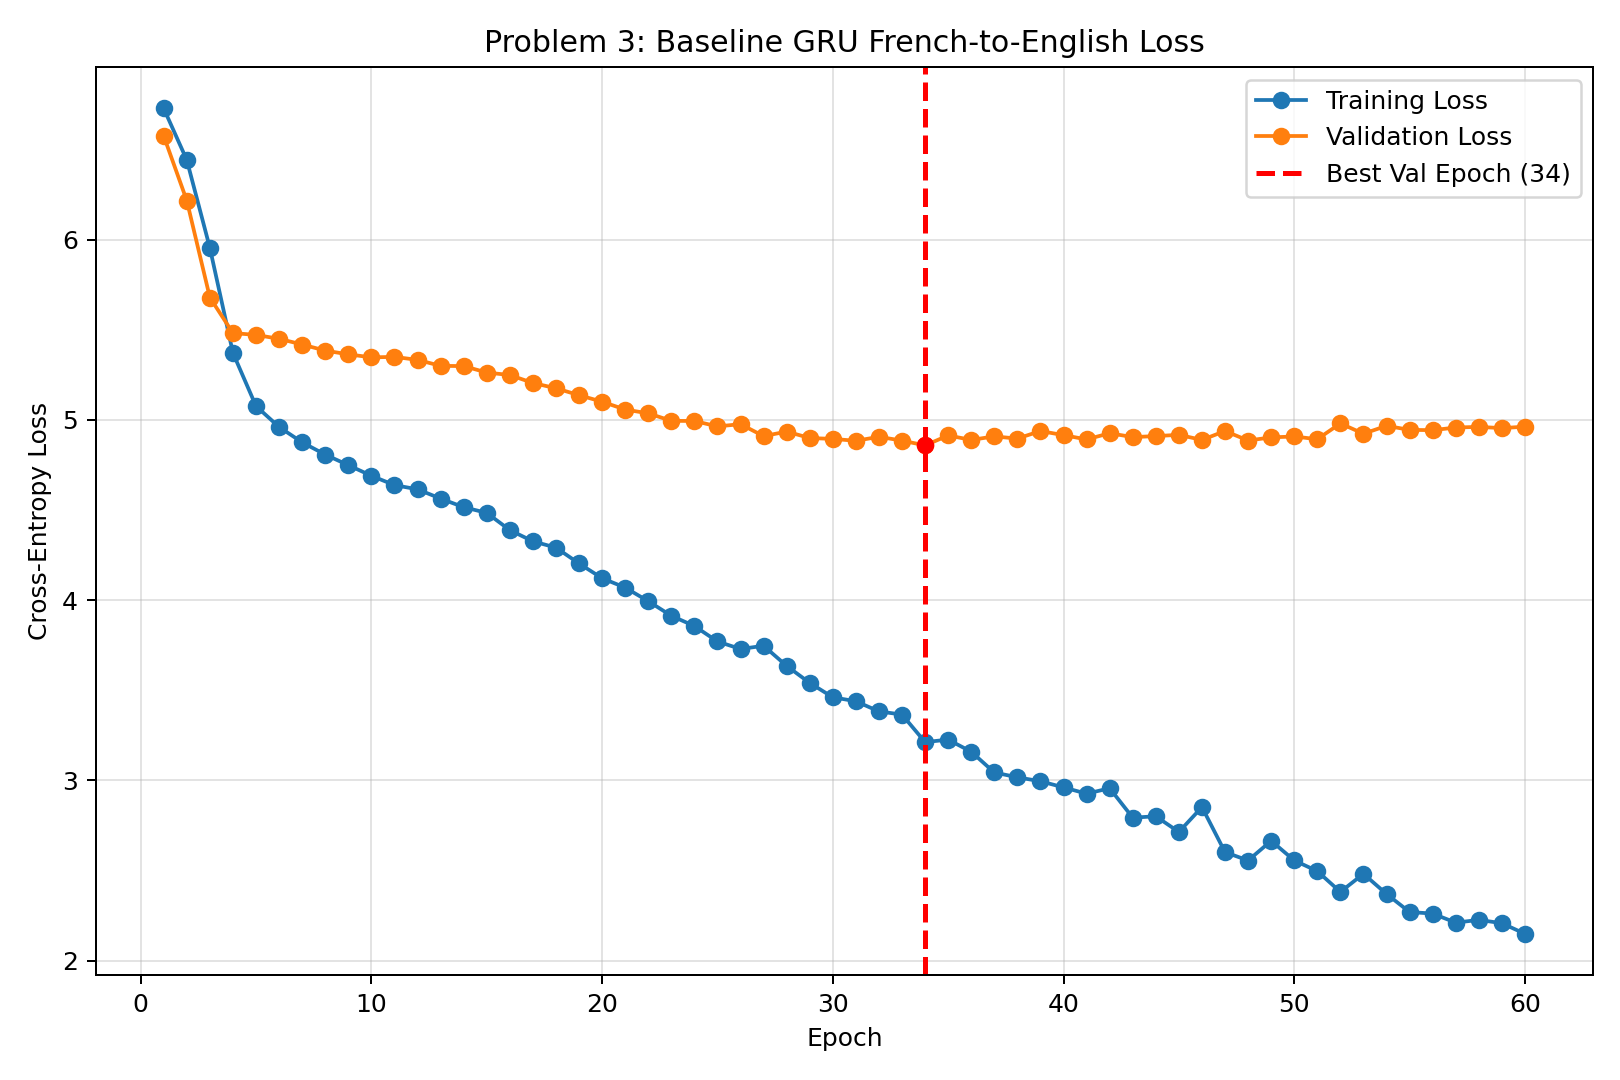

problem3_full_bleu_comparison.png


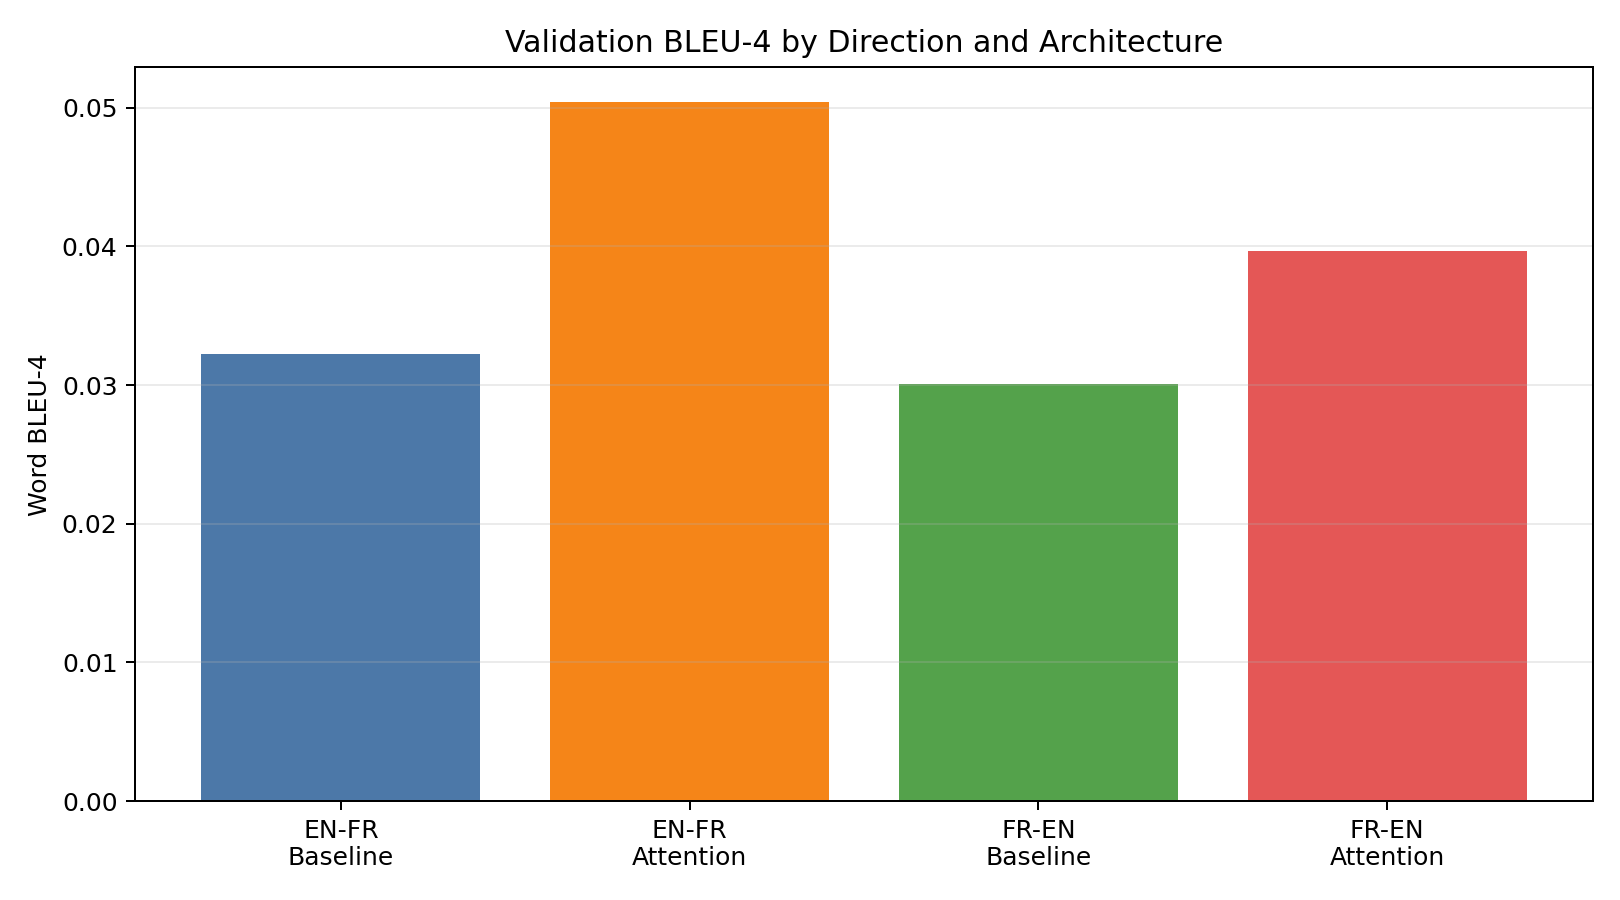

problem3_model_comparison.png


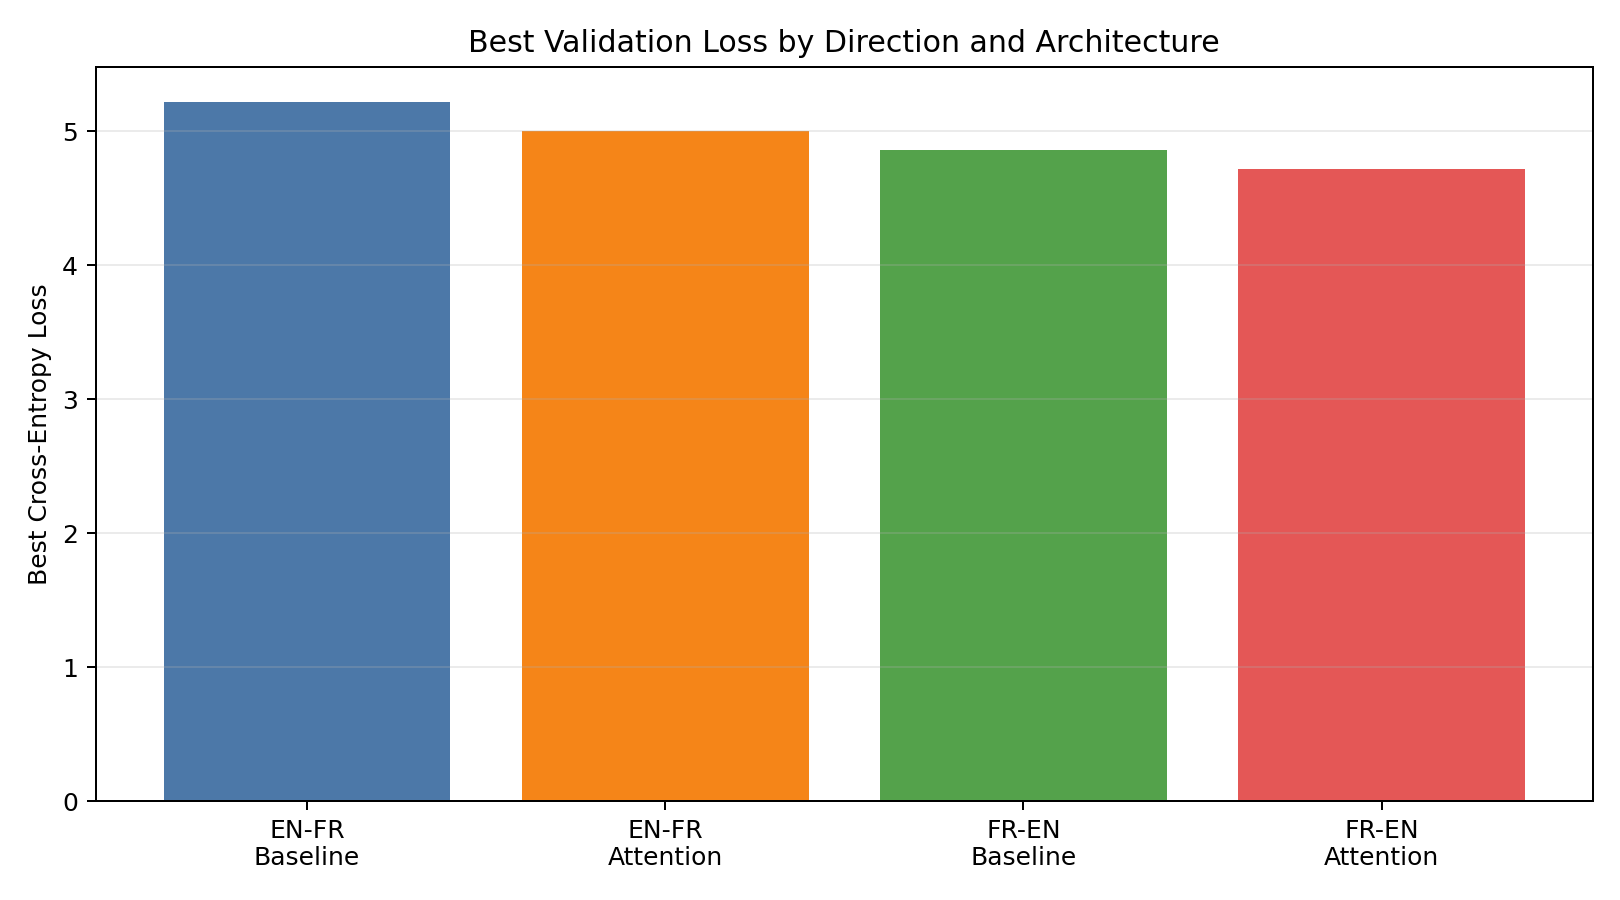

In [9]:
from IPython.display import Image, display

for path in sorted(Path('plots').glob('*.png')):
    print(path.name)
    display(Image(filename=str(path)))